In [19]:
import sys,os
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_data

In [20]:
df = load_data('data/processed/df_final.csv')
df.head()

👉 Loading: data/processed/df_final.csv


,total_load,hour,day_of_week,quarter,month,day_of_month,day_of_year,week_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,year_sin,year_cos,holiday_name
Timestamp,,,,,,,,,,,,,,,,,,
2012-01-01 00:00:00,104230.493821,0,6,1,1,1,1,52,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 01:00:00,112550.368868,1,6,1,1,1,1,52,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 02:00:00,110930.247627,2,6,1,1,1,1,52,1,0.500000,0.866025,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 03:00:00,106191.754971,3,6,1,1,1,1,52,1,0.707107,0.707107,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo
2012-01-01 04:00:00,103540.419166,4,6,1,1,1,1,52,1,0.866025,0.500000,-0.781831,0.62349,0.0,1.0,0.0,1.0,Ano Novo


In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Tách dữ liệu thực tế năm 2013 và 2014
y_2013 = df.loc['2013-01-01':'2013-12-31', 'total_load'].values
y_2014 = df.loc['2014-01-01':'2014-12-31', 'total_load'].values

# 2. Xử lý lệch dòng (nếu có) để hai mảng bằng độ dài nhau
# (Ví dụ: Nếu một năm có 8760 giờ, năm kia có 8761 do DST hoặc năm nhuận)
min_length = min(len(y_2013), len(y_2014))
y_true = y_2014[:min_length]
y_naive = y_2013[:min_length]

# 3. Tính toán các chỉ số đánh giá
mae_naive = mean_absolute_error(y_true, y_naive)
rmse_naive = np.sqrt(mean_squared_error(y_true, y_naive))
mape_naive = np.mean(np.abs((y_true - y_naive) / y_true)) * 100

print("KẾT QUẢ NAIVE BASELINE (Dựa trên Lag 1 tuần)")
print("-" * 40)
print(f"MAE  : {mae_naive:,.2f} kWh")
print(f"RMSE : {rmse_naive:,.2f} kWh")
print(f"MAPE : {mape_naive:.2f} %")

KẾT QUẢ NAIVE BASELINE (Dựa trên Lag 1 tuần)
----------------------------------------
MAE  : 14,597.06 kWh
RMSE : 21,625.73 kWh
MAPE : 6.07 %


In [22]:
# Xác định các cột tính năng (loại bỏ cột mục tiêu)
features = [col for col in df.columns if col not in ['total_load']]

# Chia tập Train (2012-2013) và Test (2014)
X_train = df.loc['2012-01-01':'2013-12-31', features]
y_train = df.loc['2012-01-01':'2013-12-31', 'total_load']

X_test = df.loc['2014-01-01':'2014-12-31', features]
y_test = df.loc['2014-01-01':'2014-12-31', 'total_load']

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (17544, 17)
Kích thước tập Test: (8760, 17)


In [23]:
import lightgbm as lgb

# Khởi tạo mô hình
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    importance_type='gain' # Để xem feature nào quan trọng nhất
)

# Huấn luyện
model.fit(
    X_train, y_train,
    categorical_feature=['holiday_name'],
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # Dừng sớm nếu không cải thiện
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 987
[LightGBM] [Info] Number of data points in the train set: 17544, number of used features: 17
[LightGBM] [Info] Start training from score 217520.717240
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	valid_0's l1: 12909.7	valid_0's l2: 3.66173e+08


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [24]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Dự báo trên tập Test
y_pred = model.predict(X_test)

# Tính toán sai số
mae_lgb = mean_absolute_error(y_test, y_pred)
mape_lgb = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\nSO SÁNH HIỆU NĂNG")
print("-" * 30)
print(f"Naive Baseline MAPE : 6.07 %")
print(f"LightGBM MAPE       : {mape_lgb:.2f} %")

if mape_lgb < 6.07:
    print(f"==> THÀNH CÔNG: Mô hình cải thiện được {6.07 - mape_lgb:.2f}%")
else:
    print("==> THẤT BẠI: Mô hình chưa tốt bằng Naive. Cần thêm Feature hoặc chỉnh tham số!")


SO SÁNH HIỆU NĂNG
------------------------------
Naive Baseline MAPE : 6.07 %
LightGBM MAPE       : 5.38 %
==> THÀNH CÔNG: Mô hình cải thiện được 0.69%


<Figure size 1000x800 with 0 Axes>

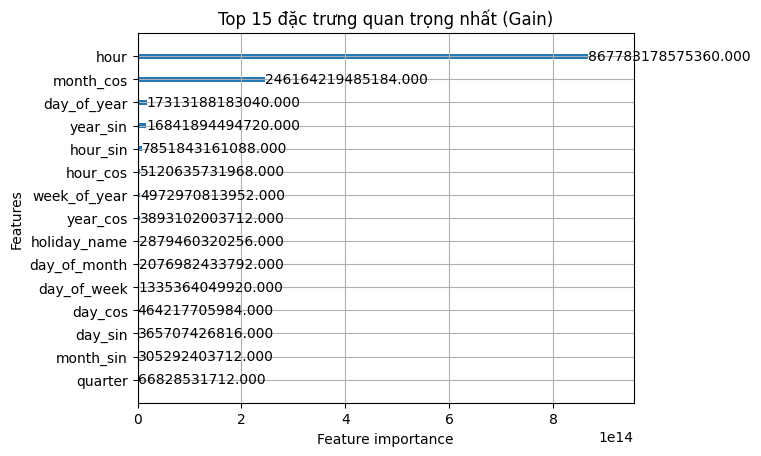

In [25]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Vẽ biểu đồ tầm quan trọng của các biến
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Top 15 đặc trưng quan trọng nhất (Gain)')
plt.show()

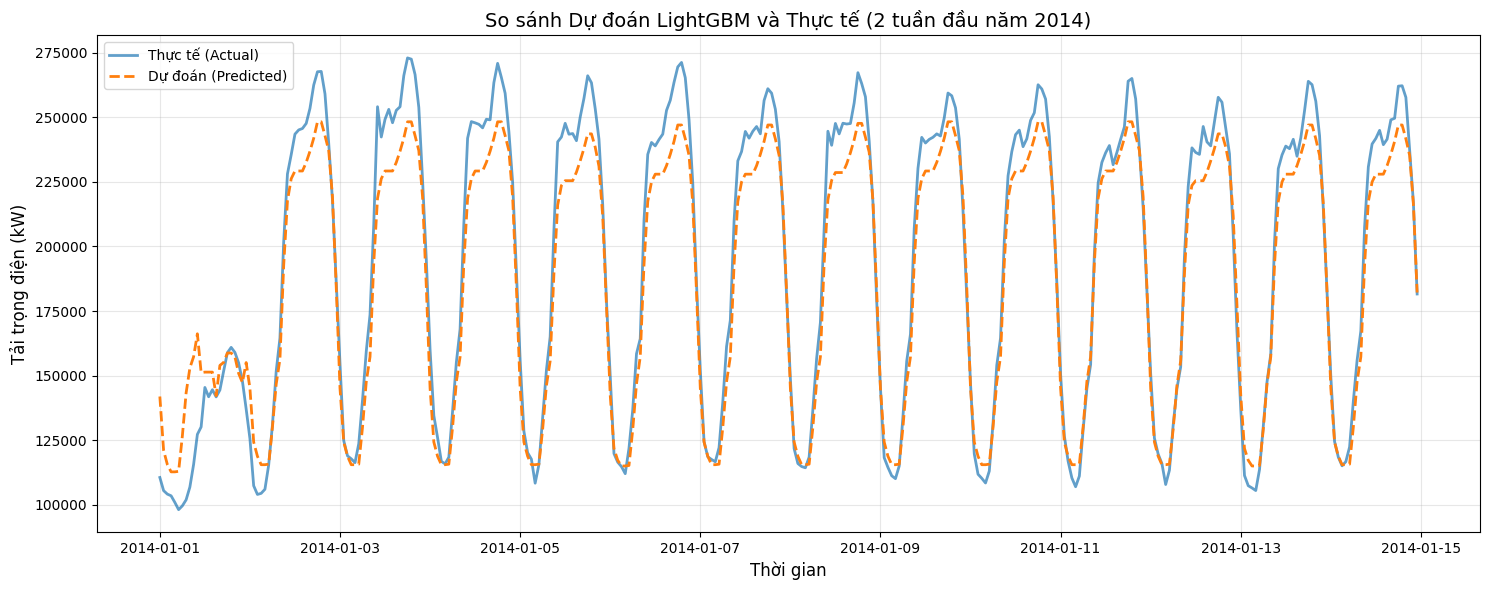

In [31]:
import matplotlib.pyplot as plt

# 1. Tạo DataFrame để so sánh
comparison_df = pd.DataFrame({
    'Thực tế': y_test.values,
    'Dự đoán': y_pred
}, index=y_test.index)

# 2. Chọn một khoảng thời gian ngắn để quan sát rõ (ví dụ 14 ngày đầu năm 2014)
plot_df = comparison_df.iloc[:24*14] 

plt.figure(figsize=(15, 6))
plt.plot(plot_df.index, plot_df['Thực tế'], label='Thực tế (Actual)', color='#1f77b4', alpha=0.7, linewidth=2)
plt.plot(plot_df.index, plot_df['Dự đoán'], label='Dự đoán (Predicted)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('So sánh Dự đoán LightGBM và Thực tế (2 tuần đầu năm 2014)', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tải trọng điện (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

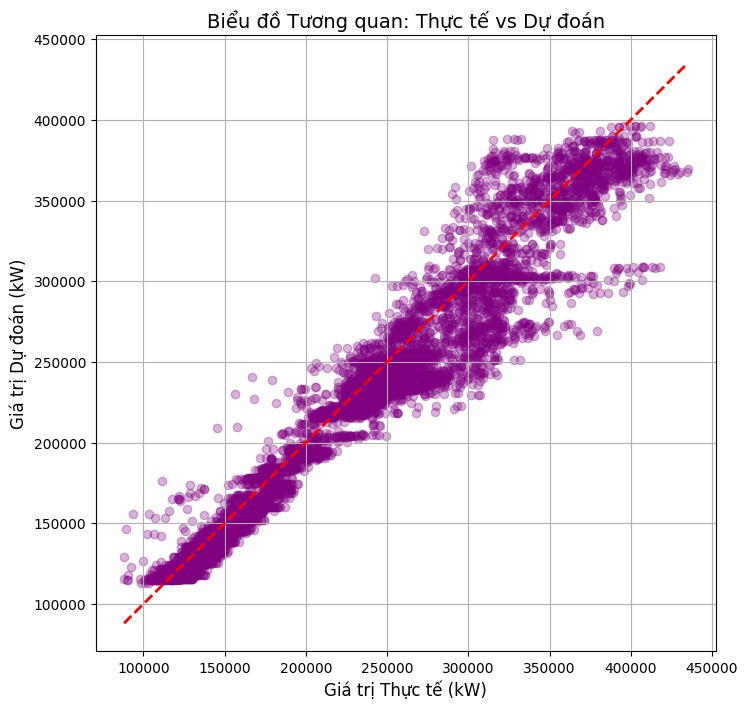

In [29]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Đường chuẩn 45 độ

plt.title('Biểu đồ Tương quan: Thực tế vs Dự đoán', fontsize=14)
plt.xlabel('Giá trị Thực tế (kW)', fontsize=12)
plt.ylabel('Giá trị Dự đoán (kW)', fontsize=12)
plt.grid(True)
plt.show()